# Generative Molecular Transformer

Overview An autoregressive Transformer model trained on the Tox21 dataset to generate valid chemical structures (SMILES). Implemented in PyTorch from scratch without using nn.Transformer layers to demonstrate understanding of Multi-Head Attention mechanisms.

Key Features

Custom Attention Implementation: Manual implementation of Query/Key/Value projections and Causal Masking.

Chem-Informatics: Integration with RDKit for validity checking and visualization.

Results: Achieved 65% validity in generated molecules after 50 epochs.

Installation pip install -r requirements.txt

Attribution Code structure adapted from J.M. Tomczak's "Introduction to Deep Generative Modeling".

Code can be downloaded from the author's Github page https://github.com/jmtomczak/intro_dgm.

In [1]:
#!pip install torch numpy matplotlib pandas scikit-learn rdkit

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
#import deepchem

from pytorch_model_summary import summary

### Dataset

This dataset is a slight modification of a widely used benchmark Tox21 (more [here](https://deepchem.readthedocs.io/en/latest/api_reference/moleculenet.html)). Each molecule is originally represented as SMILES and then tokenized (we used [`BasicSmileTokenizer`](https://deepchem.readthedocs.io/en/latest/api_reference/featurizers.html?highlight=tokenizer#basicsmilestokenizer) from [`DeepChem`](https://deepchem.readthedocs.io/en/latest/index.html)). We limit ourselves to SMILES no longer than 100 tokens and no smaller than 10 tokens. The resulting data is a matrix $7410 \times 100$ containing integers. 

In [5]:
class Tox21(Dataset):
    """A filtered version of DeepChem Tox21 dataset. (Only SMILES longer than 9 and shorter than 101, the number of token values: 112)"""

    def __init__(self, mode='train', transforms=None):
        smiles = np.load(os.path.join('molecules', 'tox21_smiles_tokenized.npy'), allow_pickle=True)
        smiles = torch.from_numpy(smiles).long()
        
        if mode == 'train':
            self.data = smiles[:6600]
        elif mode == 'val':
            self.data = smiles[6600:7000]
        else:
            self.data = smiles[7000:]

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

## Transformers: A combination of Multi-head Self-Attention, LayerNormalization and MLP

### Architecture Note: Causal Masking
To function as an Autoregressive Model (ARM), the network must generate molecules one token at a time without "peeking" at future tokens during training.

While Recurrent Neural Networks (RNNs) enforce this sequentially, Transformers process the entire sequence in parallel. To enforce causality, this implementation uses **Masked Self-Attention**. In the `MultiHeadSelfAttention` block, we utilize `torch.triu_indices` to create an upper-triangular mask. This sets all attention scores for future positions to `-inf` before the softmax step, effectively zeroing out their probability and ensuring prediction $t$ depends only on tokens $0$ to $t-1$.


In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, num_emb, num_heads=8):
        super().__init__()
        
        # hyperparams
        self.D = num_emb
        self.H = num_heads
        
        # weights for self-attention
        self.w_k = nn.Linear(self.D, self.D * self.H)
        self.w_q = nn.Linear(self.D, self.D * self.H)
        self.w_v = nn.Linear(self.D, self.D * self.H)
        
        # weights for a combination of multiple heads
        self.w_c = nn.Linear(self.D * self.H, self.D)
            
    def forward(self, x, causal=True):
        # x: B(atch) x T(okens) x D(imensionality)
        B, T, D = x.size()
        
        # keys, queries, values
        k = self.w_k(x).view(B, T, self.H, D) # B x T x H x D
        q = self.w_q(x).view(B, T, self.H, D) # B x T x H x D
        v = self.w_v(x).view(B, T, self.H, D) # B x T x H x D
        
        k = k.transpose(1, 2).contiguous().view(B * self.H, T, D) # B*H x T x D
        q = q.transpose(1, 2).contiguous().view(B * self.H, T, D) # B*H x T x D
        v = v.transpose(1, 2).contiguous().view(B * self.H, T, D) # B*H x T x D
        
        k = k / (D**0.25) # scaling 
        q = q / (D**0.25) # scaling
        
        # kq
        kq = torch.bmm(q, k.transpose(1, 2)) # B*H x T x T
        
        # if causal
        if causal:
            mask = torch.triu_indices(T, T, offset=1) #It's useful when you want to operate on or extract elements 
            #from the upper triangular portion of a matrix (including the main diagonal) without explicitly constructing 
            #the full matrix and then selecting parts.This is particularly efficient for memory and computation,
            #especially when dealing with large matrices.
            kq[..., mask[0], mask[1]] = float('-inf')
        
        # softmax
        skq = F.softmax(kq, dim=2)
        
        # self-attention
        sa = torch.bmm(skq, v) # B*H x T x D
        sa = sa.view(B, self.H, T, D) # B x H x T x D
        sa = sa.transpose(1, 2) # B x T x H x D
        sa = sa.contiguous().view(B, T, D * self.H) # B x T x D*H
        
        out = self.w_c(sa) # B x T x D
        
        return out      

### Architecture Note: Positional Encodings
Unlike RNNs, the self-attention mechanism is **permutation equivariant**—it calculates relationships between tokens based on content, not distance. Without explicit positional information, the model would treat a SMILES string like `C-O-C` identically to `C-C-O`.

To resolve this, we inject order information using **Learnable Positional Embeddings** (`self.positional_embedding`). These vectors are added to the semantic token embeddings at the input layer, allowing the model to distinguish between atoms based on their specific position in the molecular sequence.

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, num_emb, num_neurons, num_heads=4):
        super().__init__()
        
        # hyperparams
        self.D = num_emb
        self.H = num_heads
        self.neurons = num_neurons
        
        # components
        self.msha = MultiHeadSelfAttention(num_emb=self.D, num_heads=self.H)
        self.layer_norm1 = nn.LayerNorm(self.D)
        self.layer_norm2 = nn.LayerNorm(self.D)
        
        self.mlp = nn.Sequential(nn.Linear(self.D, self.neurons * self.D),
                                nn.GELU(),
                                nn.Linear(self.neurons * self.D, self.D))
    
    def forward(self, x, causal=True):
        # Multi-Head Self-Attention
        x_attn = self.msha(x, causal)
        # LayerNorm
        x = self.layer_norm1(x_attn + x)
        # MLP
        x_mlp = self.mlp(x)
        # LayerNorm
        x = self.layer_norm2(x_mlp + x)
        
        return x

### Architecture Note: Layer Normalization
Deep Transformers are notoriously difficult to train due to vanishing/exploding gradients. To stabilize training, this architecture employs **Layer Normalization** (`nn.LayerNorm`) within each `TransformerBlock`.

By normalizing the inputs across the feature dimension before passing them to the Attention and MLP layers (or after, depending on specific Pre/Post-LN configuration), we ensure consistent mean and variance, allowing for deeper networks (10 blocks in this configuration) and higher learning rates (`1e-3`).

In [8]:
class LossFun(nn.Module):
    def __init__(self,):
        super().__init__()
        
        self.loss = nn.NLLLoss(reduction='none')
    
    def forward(self, y_model, y_true, reduction='sum'):
        # y_model: B(atch) x T(okens) x V(alues)
        # y_true: B x T      
        B, T, V = y_model.size()
        
        y_model = y_model.view(B * T, V)
        y_true = y_true.view(B * T,)
        
        loss_matrix = self.loss(y_model, y_true) # B*T
        
        if reduction == 'sum':
            return torch.sum(loss_matrix)
        elif reduction == 'mean':
            loss_matrix = loss_matrix.view(B, T)
            return torch.mean(torch.sum(loss_matrix, 1))
        else:
            raise ValueError('Reduction could be either `sum` or `mean`.')

In [9]:
class Transformer(nn.Module):
    def __init__(self, num_tokens, num_token_vals, num_emb, num_neurons, num_heads=2, dropout_prob=0.1, num_blocks=10, device='cpu'):
        super().__init__()
        
        # hyperparams
        self.device = device
        self.num_tokens = num_tokens
        self.num_token_vals = num_token_vals
        self.num_emb = num_emb
        self.num_blocks = num_blocks
        
        # embedding layer
        self.embedding = torch.nn.Embedding(num_token_vals, num_emb)
        
        # positional embedding
        self.positional_embedding = nn.Embedding(num_tokens, num_emb)
        
        # transformer blocks
        self.transformer_blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.transformer_blocks.append(TransformerBlock(num_emb=num_emb, num_neurons=num_neurons, num_heads=num_heads))
        
        # output layer (logits + softmax), Q:WHY Logit?
        self.logits = nn.Sequential(nn.Linear(num_emb, num_token_vals))
        
        # dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # loss function
        self.loss_fun = LossFun()
        
    def transformer_forward(self, x, causal=True, temperature=1.0):
        # x: B(atch) x T(okens)
        # embedding of tokens
        device='cpu'
        x = self.embedding(x) # B x T x D
        # embedding of positions
        pos = torch.arange(0, x.shape[1], dtype=torch.long).unsqueeze(0).to(self.device)
        pos_emb = self.positional_embedding(pos)
        # dropout of embedding of inputs
        x = self.dropout(x + pos_emb)
        
        # transformer blocks
        for i in range(self.num_blocks):
            x = self.transformer_blocks[i](x)
        
        # output logits
        out = self.logits(x)
        
        return F.log_softmax(out/temperature, 2)
    
    @torch.no_grad()
    def sample(self, batch_size=4, temperature=1.0):
        x_seq = np.asarray([[self.num_token_vals - 1] for i in range(batch_size)])

        # sample next tokens
        for i in range(self.num_tokens-1):
            xx = torch.tensor(x_seq, dtype=torch.long, device=self.device)
            # process x and calculate log_softmax
            x_log_probs = self.transformer_forward(xx, temperature=temperature)
            # sample i-th tokens
            x_i_sample = torch.multinomial(torch.exp(x_log_probs[:,i]), 1).to(self.device)
            # update the batch with new samples
            x_seq = np.concatenate((x_seq, x_i_sample.to('cpu').detach().numpy()), 1)
        
        return x_seq
    
    @torch.no_grad()
    def top1_rec(self, x, causal=True):
        x_prob = torch.exp(self.transformer_forward(x, causal=True))[:,:-1,:].contiguous()
        _, x_rec_max = torch.max(x_prob, dim=2)
        return torch.sum(torch.mean((x_rec_max.float() == x[:,1:].float().to(device)).float(), 1).float())
    
    def forward(self, x, causal=True, temperature=1.0, reduction='mean'):
        # get log-probabilities
        log_prob = self.transformer_forward(x, causal=causal, temperature=temperature)
        
        return self.loss_fun(log_prob[:,:-1].contiguous(), x[:,1:].contiguous(), reduction=reduction)

### Auxiliary functions: training, evaluation, plotting

In [22]:
def evaluation(test_loader, name=None, model_best=None, epoch=None, device='cpu'):
    # EVALUATION
    if model_best is None:
        # load best performing model
        model_best = torch.load(name + '.model', weights_only=False).to(device)

    model_best.eval()
    loss = 0.
    rec = 1.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch.to(device), reduction='sum')
        loss = loss + loss_t.item()
        
        rec_t = model_best.top1_rec(test_batch.to(device))
        rec = rec + rec_t.item()
        
        N = N + test_batch.shape[0]
    loss = loss / N
    rec = rec / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}, rec={rec}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}, val rec={rec}')

    return loss, rec

def plot_curve(name, nll_val, ylabel='nll'):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel(ylabel)
    plt.savefig(name + '_' + ylabel + '_val_curve.pdf', bbox_inches='tight')
    plt.close()

In [11]:
def training(name, max_patience, num_epochs, model, optimizer, training_loader, val_loader, device='cpu'):
    nll_val = []
    rec_val = []
    best_nll = 1000.
    patience = 0
    device='cpu'
    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            loss = model.forward(batch.to(device))

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val, r_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)  # save for plotting
        rec_val.append(r_val)

        if e == 0:
            print('saved!')
            torch.save(model, name + '.model')
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                print('saved!')
                torch.save(model, name + '.model')
                best_nll = loss_val
                patience = 0
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)
    rec_val = np.asarray(rec_val)

    return nll_val, rec_val

### Initialize dataloaders

In [13]:
train_data = Tox21(mode='train')
val_data = Tox21(mode='val')
test_data = Tox21(mode='test')

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'transformer_gen'

### Hyperparams

### Model Configuration & Hyperparameters
The model is configured to balance computational efficiency with expressivity for the Tox21 SMILES vocabulary:

* **Attention Heads (H=8):** Multiple heads allow the model to attend to different chemical properties simultaneously (e.g., one head might focus on ring closure, another on valency).
* **Embedding Dimension (D=64):** A compact representation sufficient for the limited vocabulary size of SMILES tokens (112 unique values).
* **Depth (10 Blocks):** Deep enough to capture long-range dependencies in molecular structures, such as opening and closing rings over long distances.

In [48]:
num_tokens = 101
num_token_vals = 112
num_emb = 64
num_neurons=4
num_heads=8
num_blocks=10
causal=True

lr = 1e-3 # learning rate
num_epochs = 200 # max. number of epochs
max_patience = 10 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [49]:
evaluation

<function __main__.evaluation(test_loader, name=None, model_best=None, epoch=None, device='cpu')>

### Initialize Transformer

In [50]:
model = Transformer(num_tokens=num_tokens, num_token_vals=num_token_vals, num_emb=num_emb, num_neurons=num_neurons, num_heads=num_heads, num_blocks=num_blocks, device=device)
model = model.to(device)
# Print the summary (like in Keras)
print(summary(model, torch.zeros(1, num_tokens, dtype=torch.long).to(device), show_input=False, show_hierarchical=False))

Transformer by JT.
---------------------------------------------------------------------------
          Layer (type)        Output Shape         Param #     Tr. Param #
           Embedding-1        [1, 101, 64]           7,168           7,168
           Embedding-2        [1, 101, 64]           6,464           6,464
             Dropout-3        [1, 101, 64]               0               0
    TransformerBlock-4        [1, 101, 64]         166,016         166,016
    TransformerBlock-5        [1, 101, 64]         166,016         166,016
    TransformerBlock-6        [1, 101, 64]         166,016         166,016
    TransformerBlock-7        [1, 101, 64]         166,016         166,016
    TransformerBlock-8        [1, 101, 64]         166,016         166,016
    TransformerBlock-9        [1, 101, 64]         166,016         166,016
   TransformerBlock-10        [1, 101, 64]         166,016         166,016
   TransformerBlock-11        [1, 101, 64]         166,016         166,016
   Tr

### Let's play! Training

In [51]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

In [52]:
device 

'cpu'

In [53]:
# Training procedure
nll_val, rec_val = training(name=result_dir + name, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                           training_loader=training_loader, val_loader=val_loader)

Epoch: 0, val nll=64.78763397216797, val rec=0.8337499952316284
saved!
Epoch: 1, val nll=54.70233673095703, val rec=0.8494749975204468
saved!
Epoch: 2, val nll=49.981326751708984, val rec=0.8577000093460083
saved!
Epoch: 3, val nll=46.763358459472656, val rec=0.8637500119209289
saved!
Epoch: 4, val nll=43.999794006347656, val rec=0.8710500073432922
saved!
Epoch: 5, val nll=42.2609147644043, val rec=0.8751499915122986
saved!
Epoch: 6, val nll=40.41671371459961, val rec=0.8784500002861023
saved!
Epoch: 7, val nll=38.67744140625, val rec=0.8843000221252442
saved!
Epoch: 8, val nll=37.314358978271486, val rec=0.8871249961853027
saved!
Epoch: 9, val nll=36.00353210449219, val rec=0.891000018119812
saved!
Epoch: 10, val nll=35.24253753662109, val rec=0.8931249928474426
saved!
Epoch: 11, val nll=34.636759185791014, val rec=0.8946250009536744
saved!
Epoch: 12, val nll=33.7612956237793, val rec=0.8974750208854675
saved!
Epoch: 13, val nll=33.42655288696289, val rec=0.896150016784668
saved!
Epoc

In [55]:
test_loss, test_rec = evaluation(name=result_dir + name, test_loader=test_loader)

with open(result_dir + name + '_test_loss.txt', "w") as f:
    f.write('Test NLL: ' + str(test_loss)+'\n'+'Test REC: ' + str(test_rec))
    f.close()

plot_curve(result_dir + name, nll_val, ylabel='nll')
plot_curve(result_dir + name, rec_val, ylabel='rec')

FINAL LOSS: nll=27.498341779011053, rec=0.9166341455971322


In [56]:
##for H=4
#FINAL LOSS: nll=27.146774961890245, rec=0.9189268251744712
##for H=1
#FINAL LOSS: nll=27.463991341939785, rec=0.9144146430783155
##for H=8
#FINAL LOSS: nll=27.498341779011053, rec=0.9166341455971322

### Data visualization

#### Auxiliary functions

In [24]:
def is_valid_smiles(smiles):
    """ Using RDKit to calculate whether molecule is syntactically and semantically valid.
    """
    if smiles == "":
        return False
    try:
        return Chem.MolFromSmiles(smiles, sanitize=True) is not None
    except:
        return False

In [25]:
def plot_smiles(smiles, nrows, ncols, path=None):

    if len(smiles) < nrows * ncols:
        raise AssertionError("Provide more examples")

    fig, axes = plt.subplots(nrows, ncols)
    plt.subplots_adjust(wspace=0., hspace=0.)
    idx = 0
    for row in [idx for idx in range(nrows)]:
        for column in [idx for idx in range(ncols)]:
            ax = axes[row, column]
            # ax.set_title(f"Image ({row}, {column})")
            ax.axis('off')
            ax.imshow(Draw.MolToImage(Chem.MolFromSmiles(smiles[idx])))
            idx += 1
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.tight_layout()
    else:
        plt.show()

#### Sample new data

In [27]:
# Sample molecules
model_best = torch.load(result_dir + name + '.model', weights_only=False)
model_best = model_best.eval()

In [28]:
num_samples = 1028
x_sample = model_best.sample(batch_size=num_samples)

In [29]:
alphabet_dict_reverse = np.load(os.path.join('molecules', 'alphabet_dict_reverse.npy'), allow_pickle=True).item()

In [ ]:
smiles = []
for n in range(x_sample.shape[0]):
    s = ''
    for i in range(1, x_sample.shape[1]):
        c = alphabet_dict_reverse[x_sample[n, i]]
        if c == 'unk':
            break
        else:
            s = s + c
    if is_valid_smiles(s):
        smiles.append(s)

In [33]:
smiles

['O=C(O)C(Cl)Cl',
 'Cc1ncc(NCCO)nc1',
 'COc1ccc(C(=O)CC=C(Cl)Cl)cc1',
 'O=[PH](O)c1nc(Cl)cnc1Cl',
 'COC(=O)c1ccc(OC(C)=O)cc1',
 'N=C(N)NC(=S)NCCCSC',
 'C=CCCCCCCCCCO',
 'NCCCNC(=O)SC(=O)O',
 'CC(O)[C@H]1[C@@H](O)C[C@H](O)[C@H](O)C1',
 'CCOC(=O)C(c1ccccc1)C1=NCNCN1',
 'COc1nc(CN)cc(-c2cccc(S(N)(=O)=O)c2)c1N',
 'CC(C)CC(=O)N(c1ccc(F)c(Cl)c1)C(=O)OCCCl',
 'CO/N=C(\\CC#N)NOC(=O)C',
 'CCCCCC[N+](C)(C)CCCC',
 'CCCCN1C(=O)C(c2ccccc2)CC1',
 'CC(C)Cc1ccc(C(=O)O)cc1',
 'CN(C)CCN=Cc1c[nH]c2ccccc12',
 'CC(CCO)(C)OC(C)COCOc1ccccc1',
 'CCOP(=O)(OCC)CCSP(=O)(OCC)OC',
 'CC(C)(c1c(O)cc(O)cc1)c1ccc(Cl)cc1',
 'CCCCCCCCCOCO',
 'Nc1ccc(CO)cc1',
 'CCC(CCCO)OCCOc1ccccc1',
 'O=C(C/C=C/c1ccc(O)cc1)/C=C1C/CCCCCC(=O)OCC1',
 'O=C1NC(=O)c2cnncc21',
 'CCCCn1c(N)nc(-c2ccccc2)n1',
 'Nc1cccc2c(S(=O)(=O)O)cccc12',
 'CC(=O)[O-].[Mo]',
 'COCCCCCCCN(C)C(=O)N(CCCC)C(=O)OCCCCc1ccc(Cl)cc1OC',
 'O=C(O)CCN1CCCCCC1',
 'BrC(Br)C(Br)Br',
 'C=COC1CC(C)OC1',
 'O=C([O-])CCCOCC(=O)c1ccccc1',
 'CC(C)N1C(=O)[C@H](N[C@H]2C(=O)O)[C@@H](O

In [34]:
print(f'The percentage of valid molecules: {len(smiles)/num_samples}')
with open(result_dir + name + '_validity.txt', "w") as f:
    f.write(f'The percentage of valid molecules: {len(smiles)/num_samples}')
    f.close()

The percentage of valid molecules: 0.6498054474708171


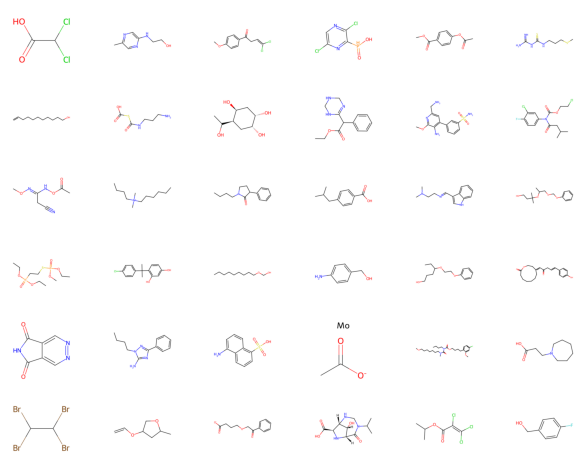

In [35]:
plot_smiles(smiles, 6, 6, path=result_dir + 'transformer_generated_molecules.png')